# Influential Outlier Metric for PISA data

In [1]:
%pip install pyreadstat optuna pingouin normflows

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 63.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 31.3 MB/s eta 0:00:00
  Created wheel for normflows: filename=normflows-1.7.3-py2.py3-none-any.whl size=87352 sha256=5182d5d21923c124da262baf36f612c0612581341f7bc0d4f8a8db43059796c6
  Stored in directory: /root/.cache/pip/wheels/a4/8a/16/ee8092d127718f6c6ac8396704ebed7637d2ae56417700e06c
Successfully built normflows


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("LocalSpark")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.0.4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import pyreadstat
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


from joblib import Parallel, delayed
from tqdm import tqdm, trange

from scipy import stats

import optuna

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
import xgboost as xgb
from xgboost.callback import EarlyStopping

from iom import InfluentialOutlierMetric

In [9]:
import numpy as np
from scipy.stats import chi2, kstest, cramervonmises, norm, jarque_bera
from scipy.special import logsumexp
from pingouin import multivariate_normality


# ============================================================
# Input handling: diagonal covariance only
# ============================================================
def coerce_diag_gmm_inputs(X, weights, means, scales):
    """
    Coerce inputs for a diagonal Gaussian mixture.

    Parameters
    ----------
    X : array-like, shape (n,) or (n, d)
        Latent observations after normalizing flow.
    weights : array-like, shape (m,)
        Mixture weights.
    means : array-like, shape (m,) or (m, d)
        Component means.
    scales : array-like, shape (m,) or (m, d)
        Component standard deviations, not variances.

    Returns
    -------
    X : array, shape (n, d)
    weights : array, shape (m,)
    means : array, shape (m, d)
    scales : array, shape (m, d)
    """
    X = np.asarray(X, dtype=float)
    weights = np.asarray(weights, dtype=float)
    means = np.asarray(means, dtype=float)
    scales = np.asarray(scales, dtype=float)

    if X.ndim == 1:
        X = X[:, None]

    if means.ndim == 1:
        means = means[:, None]

    if scales.ndim == 1:
        scales = scales[:, None]

    m, d = means.shape

    if weights.shape != (m,):
        raise ValueError(f"weights shape {weights.shape}, expected ({m},).")

    if scales.shape != (m, d):
        raise ValueError(f"scales shape {scales.shape}, expected ({m},{d}).")

    if X.shape[1] != d:
        raise ValueError(
            f"X has dimension {X.shape[1]}, but means has dimension {d}."
        )

    if np.any(scales <= 0):
        raise ValueError("All scales must be positive standard deviations.")

    weights = weights / weights.sum()

    return X, weights, means, scales


# ============================================================
# Diagonal Gaussian log density
# ============================================================
def diag_gaussian_logpdf(X, mean, scale):
    """
    Log density of N(mean, diag(scale^2)).

    X     : shape (n, d)
    mean  : shape (d,)
    scale : shape (d,)
    """
    z = (X - mean) / scale
    d = X.shape[1]

    return (
        -0.5 * np.sum(z**2, axis=1)
        - np.sum(np.log(scale))
        - 0.5 * d * np.log(2.0 * np.pi)
    )


# ============================================================
# Responsibilities and hard assignment
# ============================================================
def diag_gmm_responsibilities(X, weights, means, scales):
    """
    Compute posterior responsibilities:

        gamma_ik = P(component k | X_i)
    """
    X, weights, means, scales = coerce_diag_gmm_inputs(
        X, weights, means, scales
    )

    n = X.shape[0]
    m = len(weights)

    logp = np.empty((n, m), dtype=float)

    for k in range(m):
        logp[:, k] = (
            np.log(weights[k])
            + diag_gaussian_logpdf(
                X,
                mean=means[k],
                scale=scales[k],
            )
        )

    log_gamma = logp - logsumexp(logp, axis=1, keepdims=True)
    gamma = np.exp(log_gamma)

    return gamma


def hard_assign_modes(X, weights, means, scales):
    """Assign each observation to the most likely mixture component."""
    gamma = diag_gmm_responsibilities(X, weights, means, scales)
    labels = gamma.argmax(axis=1)
    max_resp = gamma.max(axis=1)

    return labels, gamma, max_resp


# ============================================================
# Whiten residuals after hard assignment
# ============================================================
def whiten_by_assigned_mode_diag(X, weights, means, scales):
    """
    Assign observations to their most likely mode and whiten using that mode.

        R_ij = (X_ij - mu_{k,j}) / sigma_{k,j}

    Under the fitted mixture:

        R_i ~ N(0, I_d)

    and

        Q_i = sum_j R_ij^2 ~ chi2_d.
    """
    X, weights, means, scales = coerce_diag_gmm_inputs(
        X, weights, means, scales
    )

    labels, gamma, max_resp = hard_assign_modes(
        X, weights, means, scales
    )

    n, d = X.shape
    m = len(weights)

    R = np.empty_like(X, dtype=float)

    for k in range(m):
        idx = labels == k

        if not np.any(idx):
            continue

        R[idx] = (X[idx] - means[k]) / scales[k]

    Q = np.sum(R**2, axis=1)

    return {
        "R": R,
        "Q": Q,
        "labels": labels,
        "gamma": gamma,
        "max_resp": max_resp,
        "X": X,
        "weights": weights,
        "means": means,
        "scales": scales,
        "n": n,
        "d": d,
        "m": m,
    }


# ============================================================
# Normality test by mode
# ============================================================
def normality_by_mode(R, labels, min_n=20, alpha=0.05):
    """
    Test normality within each assigned mode.

    Jarque-Bera is used when d = 1 and Henze-Zirkler when d >= 2.
    """
    R = np.asarray(R, dtype=float)
    labels = np.asarray(labels)

    n, d = R.shape
    rows = []

    for k in np.unique(labels):
        idx = labels == k
        Rk = R[idx]
        nk = Rk.shape[0]

        row = {
            "mode": int(k),
            "n": int(nk),
            "test": None,
            "stat": np.nan,
            "pvalue": np.nan,
            "normal": None,
            "note": "",
        }

        if nk < min_n:
            row["note"] = f"Skipped: n < {min_n}"
            rows.append(row)
            continue

        if d == 1:
            jb = jarque_bera(Rk[:, 0])

            row.update({
                "test": "Jarque-Bera",
                "stat": float(jb.statistic),
                "pvalue": float(jb.pvalue),
                "normal": bool(jb.pvalue > alpha),
                "note": "OK",
            })

        else:
            hz = multivariate_normality(Rk, alpha=alpha)

            row.update({
                "test": "Henze-Zirkler",
                "stat": float(hz.hz),
                "pvalue": float(hz.pval),
                "normal": bool(hz.normal),
                "note": "OK",
            })

        rows.append(row)

    return rows


# ============================================================
# Stouffer method for combining mode-level normality p-values
# ============================================================
def stouffer_method(pvals):
    """
    Combine p-values using Stouffer's method with equal weights.
    """
    pvals = np.asarray(pvals, dtype=float)
    pvals = pvals[~np.isnan(pvals)]

    if len(pvals) == 0:
        return {
            "stat": np.nan,
            "pvalue": np.nan,
            "n_tests": 0,
        }

    pvals = np.clip(
        pvals,
        np.finfo(float).tiny,
        1.0 - np.finfo(float).eps
    )

    z = norm.ppf(1.0 - pvals)
    z_combined = np.sum(z) / np.sqrt(len(z))
    p_combined = 1.0 - norm.cdf(z_combined)

    return {
        "stat": float(z_combined),
        "pvalue": float(p_combined),
        "n_tests": int(len(pvals)),
    }


# ============================================================
# Pooled chi-square tests
# ============================================================
def pooled_chi2_tests(Q, d):
    """Test pooled Q_i = ||R_i||^2 against chi2_d."""
    Q = np.asarray(Q, dtype=float)

    ks = kstest(Q, chi2(df=d).cdf)
    cvm = cramervonmises(Q, chi2(df=d).cdf)

    tail = chi2.sf(Q, df=d)

    return {
        "ks_stat": float(ks.statistic),
        "ks_pvalue": float(ks.pvalue),
        "cvm_stat": float(cvm.statistic),
        "cvm_pvalue": float(cvm.pvalue),
        "Q_mean": float(np.mean(Q)),
        "Q_median": float(np.median(Q)),
        "Q_max": float(np.max(Q)),
        "tail_min": float(np.min(tail)),
        "n_tail_lt_0.05": int(np.sum(tail < 0.05)),
        "n_tail_lt_0.01": int(np.sum(tail < 0.01)),
        "n_tail_lt_0.001": int(np.sum(tail < 0.001)),
    }


# ============================================================
# Mode-level summaries
# ============================================================
def mode_summaries_diag(R, Q, labels, max_resp, weights, d, min_n=20):
    """Return assignment and chi-square diagnostics by mixture mode."""
    R = np.asarray(R, dtype=float)
    Q = np.asarray(Q, dtype=float)
    labels = np.asarray(labels)
    max_resp = np.asarray(max_resp, dtype=float)
    weights = np.asarray(weights, dtype=float)

    m = len(weights)
    n = len(labels)

    rows = []

    for k in range(m):
        idx = labels == k
        nk = int(np.sum(idx))

        if nk == 0:
            rows.append({
                "mode": k,
                "n": 0,
                "assigned_weight": 0.0,
                "target_weight": float(weights[k]),
                "mean_max_resp": np.nan,
                "median_max_resp": np.nan,
                "min_max_resp": np.nan,
                "Q_mean": np.nan,
                "Q_median": np.nan,
                "Q_max": np.nan,
                "ks_pvalue": np.nan,
                "cvm_pvalue": np.nan,
            })
            continue

        Qk = Q[idx]

        if nk >= min_n:
            ks = kstest(Qk, chi2(df=d).cdf)
            cvm = cramervonmises(Qk, chi2(df=d).cdf)
            ks_p = float(ks.pvalue)
            cvm_p = float(cvm.pvalue)
        else:
            ks_p = np.nan
            cvm_p = np.nan

        rows.append({
            "mode": k,
            "n": nk,
            "assigned_weight": float(nk / n),
            "target_weight": float(weights[k]),
            "mean_max_resp": float(max_resp[idx].mean()),
            "median_max_resp": float(np.median(max_resp[idx])),
            "min_max_resp": float(max_resp[idx].min()),
            "Q_mean": float(Qk.mean()),
            "Q_median": float(np.median(Qk)),
            "Q_max": float(Qk.max()),
            "ks_pvalue": ks_p,
            "cvm_pvalue": cvm_p,
        })

    return rows


# ============================================================
# Main workflow
# ============================================================
def whitened_mode_normality_workflow_diag(
    X,
    weights,
    means,
    scales,
    min_mode_n=20,
    alpha=0.05,
    verbose=True,
):
    """
    Run diagnostics for a diagonal Gaussian-mixture latent distribution.

    Observations are assigned to their most likely mode, whitened within mode,
    tested for normality, combined using Stouffer's method, and pooled squared
    residuals are tested against chi2_d.

    Parameters
    ----------
    X : array, shape (n,) or (n, d)
        Latent values after normalizing flow.
    weights : array, shape (m,)
        Mixture weights.
    means : array, shape (m,) or (m, d)
        Component means.
    scales : array, shape (m,) or (m, d)
        Diagonal component standard deviations.
    min_mode_n : int, default=20
        Minimum observations required for a mode-level test.
    alpha : float, default=0.05
        Significance level for normality testing.
    verbose : bool, default=True
        Print diagnostic results.
    """
    res = whiten_by_assigned_mode_diag(
        X, weights, means, scales
    )

    R = res["R"]
    Q = res["Q"]
    labels = res["labels"]
    gamma = res["gamma"]
    max_resp = res["max_resp"]

    n = res["n"]
    d = res["d"]
    m = res["m"]

    assignment = {
        "mean_max_resp": float(np.mean(max_resp)),
        "median_max_resp": float(np.median(max_resp)),
        "min_max_resp": float(np.min(max_resp)),
        "frac_gt_0.80": float(np.mean(max_resp > 0.80)),
        "frac_gt_0.90": float(np.mean(max_resp > 0.90)),
        "frac_gt_0.95": float(np.mean(max_resp > 0.95)),
        "frac_gt_0.99": float(np.mean(max_resp > 0.99)),
        "assigned_counts": np.bincount(labels, minlength=m),
        "assigned_weights": np.bincount(labels, minlength=m) / n,
        "target_weights": res["weights"],
    }

    normality_results = normality_by_mode(
        R=R,
        labels=labels,
        min_n=min_mode_n,
        alpha=alpha,
    )

    normality_pvals = np.array([
        row["pvalue"]
        for row in normality_results
        if row["pvalue"] == row["pvalue"]
    ])

    stouffer_normality = stouffer_method(normality_pvals)

    pooled = pooled_chi2_tests(Q, d=d)

    mode_summary = mode_summaries_diag(
        R=R,
        Q=Q,
        labels=labels,
        max_resp=max_resp,
        weights=res["weights"],
        d=d,
        min_n=min_mode_n,
    )

    result = {
        "X": res["X"],
        "weights": res["weights"],
        "means": res["means"],
        "scales": res["scales"],
        "R": R,
        "Q": Q,
        "labels": labels,
        "gamma": gamma,
        "max_resp": max_resp,
        "assignment": assignment,
        "normality_by_mode": normality_results,
        "stouffer_normality": stouffer_normality,
        "pooled_chi2": pooled,
        "mode_summary": mode_summary,
        "n": n,
        "d": d,
        "m": m,
    }

    if verbose:
        print(
            f"--- Whitened mode-normality diagnostics "
            f"(n={n}, d={d}, m={m}) ---"
        )

        print("\n[1] Normality by assigned mode")
        for row in normality_results:
            print(
                f"    mode: {row['mode']}  "
                f"n: {row['n']}  "
                f"test: {row['test']}  "
                f"pvalue: {row['pvalue']:.4f}"
            )

        print("\n[1b] Stouffer combined normality p-value")
        print(f"     z = {stouffer_normality['stat']:.4f}")
        print(f"     p = {stouffer_normality['pvalue']:.4g}")
        print(f"     n tests = {stouffer_normality['n_tests']}")

        print("\n[2] Pooled Q against chi-square")
        print(f"    KS p-value:  {pooled['ks_pvalue']:.4f}")
        print(f"    CvM p-value: {pooled['cvm_pvalue']:.4f}")
        print(
            f"    Q mean:      {pooled['Q_mean']:.4f}  "
            f"expected approx d={d}"
        )
        print(f"    Q max:       {pooled['Q_max']:.4f}")
        print(f"    min tail p:  {pooled['tail_min']:.4g}")

    return result

In [10]:

import numpy as np
import pandas as pd

from scipy import stats
from scipy.special import kv, gamma
from scipy.integrate import quad
from scipy.optimize import brentq

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import normflows as nf
from tqdm import tqdm


class ConditionalFlowFixedBase(nf.NormalizingFlow):
    """
    Normalizing flow with optional context and a fixed base distribution.

    If context is provided, the flow models z = f(x | c). Otherwise it behaves
    as an unconditional flow z = f(x). Context affects only the transformations,
    not the Gaussian-mixture base distribution.
    """

    def forward(self, z, context=None):
        """Transform latent values to the data space."""
        for flow in self.flows:
            z, _ = flow(z, context=context)
        return z

    def forward_and_log_det(self, z, context=None):
        """Transform latent values and return the accumulated log-Jacobian."""
        log_det = torch.zeros(len(z), dtype=z.dtype, device=z.device)

        for flow in self.flows:
            z, log_d = flow(z, context=context)
            log_det += log_d

        return z, log_det

    def inverse(self, x, context=None):
        """Transform observations from the data space to the latent space."""
        for i in range(len(self.flows) - 1, -1, -1):
            x, _ = self.flows[i].inverse(x, context=context)

        return x

    def inverse_and_log_det(self, x, context=None):
        """Transform observations to latent space and return the log-Jacobian."""
        log_det = torch.zeros(len(x), dtype=x.dtype, device=x.device)

        for i in range(len(self.flows) - 1, -1, -1):
            x, log_d = self.flows[i].inverse(x, context=context)
            log_det += log_d

        return x, log_det

    def log_prob(self, x, context=None):
        """Evaluate observation-level log-density under the flow."""
        z, log_det = self.inverse_and_log_det(x, context=context)
        return self.q0.log_prob(z) + log_det

    def forward_kld(self, x, context=None):
        """Return the negative mean log-likelihood training objective."""
        return -torch.mean(self.log_prob(x, context=context))

    def sample(self, num_samples=1, context=None):
        """Draw samples from the fitted flow."""
        z, log_q = self.q0(num_samples)

        for flow in self.flows:
            z, log_det = flow(z, context=context)
            log_q -= log_det

        return z, log_q


class InfluentialOutlierMetric:
    """
    Compute the Influential Outlier Metric (IOM) using normalizing flows.

    The class transforms SHAP and residual quantities to Gaussian-mixture latent
    distributions, tunes Jacobian regularization using goodness-of-fit tests,
    and combines the transformed components into the final IOM.
    """

    def __init__(self):
        """Initialize the IOM object."""
        self.i_star = None
        self.results_shap = None
        self.results_resid = None

    def norm_flow(
        self,
        data,
        context=None,
        K=None,
        hidden=None,
        layers=None,
        epoch=None,
        lam=None,
        loc=None,
        scale=None,
        tail_bound=3,
        num_bins=8,
        test_size=0.2,
        random_state=42,
        torch_seed=42
    ):
        """
        Fit a neural spline flow with optional conditioning.

        Parameters
        ----------
        data : array-like
            Observations to transform.
        context : array-like, optional
            Conditioning variables aligned with `data`.
        K : int
            Number of spline transformations.
        hidden : int
            Hidden units in each spline conditioner.
        layers : int
            Hidden blocks in each spline conditioner.
        epoch : int
            Number of training epochs.
        lam : float
            Jacobian regularization strength.
        loc, scale : sequence
            Initial means and scales of the Gaussian-mixture base.
        tail_bound : float, default=3
            Spline tail boundary.
        num_bins : int, default=8
            Number of spline bins.
        test_size : float, default=0.2
            Fraction used for transport-distance evaluation.
        random_state : int, default=42
            Train/test split seed.
        torch_seed : int, default=42
            PyTorch random seed.

        Returns
        -------
        mod : ConditionalFlowFixedBase
            Fitted normalizing flow.
        z_all : ndarray
            Latent representation of all observations.
        dist_sq : ndarray
            Held-out squared transport distances.
        """

        torch.manual_seed(torch_seed)
        torch.cuda.manual_seed_all(torch_seed)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        torch.use_deterministic_algorithms(True, warn_only=True)
        print(device)

        data = np.asarray(data)

        if data.ndim == 1:
            data = data.reshape(-1, 1)

        latent_size = data.shape[1]

        if context is not None:
            context = np.asarray(context)

            if context.ndim == 1:
                context = context.reshape(-1, 1)

            if len(data) != len(context):
                raise ValueError(
                    f"`data` and `context` must have the same number of rows; "
                    f"got {len(data)} and {len(context)}."
                )

            context_size = context.shape[1]

        idx = np.arange(len(data))

        idx_train, idx_test = train_test_split(
            idx,
            test_size=test_size,
            random_state=random_state
        )

        x_train = data[idx_train]
        x_test = data[idx_test]

        x_scaler = StandardScaler(with_std=False)
        x_train_s = x_scaler.fit_transform(x_train).astype(np.float32)
        x_test_s = x_scaler.transform(x_test).astype(np.float32)
        x_all_s = x_scaler.transform(data).astype(np.float32)

        if context is not None:
            c_train = context[idx_train]
            c_test = context[idx_test]

            c_scaler = StandardScaler()
            c_train_s = c_scaler.fit_transform(c_train).astype(np.float32)
            c_test_s = c_scaler.transform(c_test).astype(np.float32)
            c_all_s = c_scaler.transform(context).astype(np.float32)

        else:
            c_scaler = None
            c_train_s = None
            c_test_s = None
            c_all_s = None

        flows = []

        for _ in range(K):
            if context is None:
                flows += [
                    nf.flows.AutoregressiveRationalQuadraticSpline(
                        latent_size,
                        layers,
                        hidden,
                        permute_mask=True,
                        init_identity=True,
                        tail_bound=tail_bound,
                        num_bins=num_bins,
                    )
                ]

            else:
                flows += [
                    nf.flows.AutoregressiveRationalQuadraticSpline(
                        latent_size,
                        layers,
                        hidden,
                        num_context_channels=context_size,
                        permute_mask=True,
                        init_identity=True,
                        tail_bound=tail_bound,
                        num_bins=num_bins,
                    )
                ]

        q0 = nf.distributions.GaussianMixture(
            n_modes=len(loc),
            dim=latent_size,
            loc=[
                np.array([loc[i]] * latent_size, dtype=np.float32)
                for i in range(len(loc))
            ],
            scale=[
                np.array([scale[i]] * latent_size, dtype=np.float32)
                for i in range(len(scale))
            ],
            trainable=True,
        )

        mod = ConditionalFlowFixedBase(q0, flows).float().to(device)

        mod.x_scaler = x_scaler
        mod.context_scaler = c_scaler

        x_train_t = torch.tensor(
            x_train_s,
            dtype=torch.float32,
            device=device
        )

        x_test_t = torch.tensor(
            x_test_s,
            dtype=torch.float32,
            device=device
        )

        x_all_t = torch.tensor(
            x_all_s,
            dtype=torch.float32,
            device=device
        )

        if context is not None:
            c_train_t = torch.tensor(
                c_train_s,
                dtype=torch.float32,
                device=device
            )

            c_test_t = torch.tensor(
                c_test_s,
                dtype=torch.float32,
                device=device
            )

            c_all_t = torch.tensor(
                c_all_s,
                dtype=torch.float32,
                device=device
            )

        else:
            c_train_t = None
            c_test_t = None
            c_all_t = None

        optimizer = torch.optim.AdamW(mod.parameters(), lr=3e-4)

        mod.train()

        for _ in tqdm(range(epoch), desc="Normalizing flow"):
            optimizer.zero_grad()

            _, jac = mod.inverse_and_log_det(
                x_train_t,
                context=c_train_t
            )

            loss = (
                mod.forward_kld(
                    x_train_t,
                    context=c_train_t
                )
                + lam * torch.mean(jac ** 2)
            )

            if torch.isfinite(loss):
                loss.backward()
                optimizer.step()

        mod.eval()

        with torch.no_grad():

            z_test = mod.inverse(
                x_test_t,
                context=c_test_t
            )

            dist_sq = torch.norm(
                z_test - x_test_t,
                dim=1
            ) ** 2

            z_all = mod.inverse(
                x_all_t,
                context=c_all_t
            ).cpu().numpy()

        return mod, z_all, dist_sq.cpu().numpy()

    def find_best_lambda(
        self,
        data,
        context=None,
        lambdas=None,
        K=None,
        hidden=None,
        layers=None,
        epoch=None,
        loc=None,
        scale=None,
        tail_bound=None,
        num_bins=None,
        alpha=0.15,
        torch_seed=42
    ):
        """
        Select the largest Jacobian penalty satisfying the latent
        goodness-of-fit criteria.

        Returns a dictionary containing the selected model, latent values,
        mixture parameters, preprocessing scalers, transport distances, and
        chi-square-transformed values.
        """

        if lambdas is None:
            lambdas = np.concatenate([
                np.array([0]),
                np.exp(np.linspace(-5, 1, 10))
            ])

        data = np.asarray(data)

        if data.ndim == 1:
            data = data.reshape(-1, 1)

        z_last_pass = None
        mod_last_pass = None
        dist_pass = None
        lam_final = None
        test_results_last_pass = None

        for j, lam in enumerate(lambdas):
            print(f"lambda: {lam}")

            mod, z, dist = self.norm_flow(
                data,
                context,
                K,
                hidden,
                layers,
                epoch,
                lam,
                loc,
                scale,
                tail_bound=tail_bound,
                num_bins=num_bins,
                torch_seed=torch_seed
            )

            weights = np.exp(
                mod.q0.weight_scores.cpu().detach().numpy()
            )[0]

            weights /= weights.sum()

            weights = [
                weights[i]
                for i in range(len(loc))
            ]

            means = [
                mod.q0.loc.cpu().detach().numpy()[0][i]
                for i in range(len(loc))
            ]

            scales = [
                np.exp(
                    mod.q0.log_scale.cpu().detach().numpy()
                )[0, i]
                for i in range(len(scale))
            ]

            test_results = whitened_mode_normality_workflow_diag(
                z,
                weights,
                means,
                scales,
                min_mode_n=20,
                alpha=0.05,
                verbose=True,
            )

            mode_pvalues = [
                row["pvalue"]
                for row in test_results["normality_by_mode"]
                if np.isfinite(row["pvalue"])
            ]
            all_modes_tested = len(mode_pvalues) == test_results["m"]

            pval = passes = (
                all_modes_tested
                and min(mode_pvalues) > 0.01
                and test_results["stouffer_normality"]["pvalue"] > 0.05
                and test_results["pooled_chi2"]["cvm_pvalue"] > 0.05
            )

            if pval:
                z_last_pass = z
                mod_last_pass = mod
                lam_final = lam
                dist_pass = dist
                test_results_last_pass = test_results

            else:
                break

        if z_last_pass is None:
            raise RuntimeError(
                "Increase complexity of normalizing flow."
            )

        print(f"Final lambda: {lam_final:.4f}")
        print(f"Mean test distance: {dist_pass.mean():.4f}")

        weights = np.exp(
            mod_last_pass.q0.weight_scores.cpu().detach().numpy()
        )[0]

        weights /= weights.sum()

        weights = [
            np.array(weights[i])
            for i in range(len(loc))
        ]

        means = [
            mod_last_pass.q0.loc.cpu().detach().numpy()[0][i]
            for i in range(len(loc))
        ]

        scales = [
            np.exp(
                mod_last_pass.q0.log_scale.cpu().detach().numpy()
            )[0, i]
            for i in range(len(loc))
        ]

        print(
            f"Final weights: "
            f"{[np.round(x, 4) for x in weights]}"
        )

        print(
            f"Final means: "
            f"{[np.round(x, 4) for x in means]}"
        )

        print(
            f"Final scales: "
            f"{[np.round(x, 4) for x in scales]}"
        )

        return {
            "lambda": lam_final,
            "model": mod_last_pass,
            "x_scaler": mod_last_pass.x_scaler,
            "context_scaler": mod_last_pass.context_scaler,
            "latent": (
                z_last_pass
                if z_last_pass.shape[1] > 1
                else z_last_pass.reshape(-1)
            ),
            "weights": weights,
            "means": means,
            "scales": scales,
            "test_distance": dist_pass,
            "chi_z": test_results_last_pass["Q"],
        }

    @staticmethod
    def base_parameter_count(n_modes, dim):
        """
        Return the number of free parameters in a diagonal Gaussian-mixture base.
        """
        return 2 * n_modes * dim + (n_modes - 1)

    @staticmethod
    def select_flow_by_transport_modes(
        tune_results,
        dim=1,
        rho=None
    ):
        """
        Select the flow minimizing transport distance plus a complexity penalty.

        The score is M + rho * K_m, where M is mean held-out transport distance
        and K_m is the number of Gaussian-mixture base parameters.
        """

        n_val = len(tune_results)

        if rho is None:
            rho = np.log(n_val) / n_val

        table = []

        for idx, res in enumerate(tune_results):
            n_modes = len(res["weights"])
            M = float(np.mean(res["test_distance"]))

            K_m = InfluentialOutlierMetric.base_parameter_count(
                n_modes=n_modes,
                dim=dim
            )

            score = M + rho * K_m

            table.append({
                "index": idx,
                "M": M,
                "n_modes": n_modes,
                "K_m": K_m,
                "rho": rho,
                "score": score,
            })

        selected = min(
            table,
            key=lambda x: x["score"]
        )

        return {
            "selected_index": selected["index"],
            "table": table,
        }

    @staticmethod
    def find_threshold(
        p,
        alpha=[0.05, 0.01],
        bracket=(1e-8, 1000)
    ):
        """
        Compute critical IOM thresholds from the chi-square product distribution.
        """

        def chi_prod(w, m1, m2=1):
            return (
                w ** ((m1 + m2) / 4 - 1)
                / (
                    2 ** ((m1 + m2) / 2 - 1)
                    * gamma(m1 / 2)
                    * gamma(m2 / 2)
                )
                * kv(
                    (m1 - m2) / 2,
                    np.sqrt(w)
                )
            )

        def survival_prob(i, m1, m2=1):
            val, _ = quad(
                chi_prod,
                i,
                np.inf,
                args=(m1, m2)
            )

            return val

        i_star = []

        for a in alpha:
            func = lambda i: survival_prob(i, p, 1) - a

            i_star.append(
                brentq(
                    func,
                    bracket[0],
                    bracket[1]
                )
            )

        print(f"Threshold at 0.05: {i_star[0]:.3f}")
        print(f"Threshold at 0.01: {i_star[1]:.3f}")

        return i_star

    def IOM(self, results_shap, results_resid):
        """
        Compute the IOM as the product of the chi-square-transformed SHAP and
        residual components.
        """

        self.results_shap = results_shap
        self.results_resid = results_resid

        self.IOM_ = pd.Series(
            results_shap["chi_z"]
            * self.results_resid["chi_z"],
            name="IOM"
        )

        return self.IOM_


## MEGB

In [5]:
class MEGB_CPU:
    def __init__(
        self,
        xgb_params=None,
        max_iter=6,
        tol=1e-4,
        random_state=42,
    ):
        xgb_params = dict(xgb_params or {})

        xgb_params.setdefault("learning_rate", 0.05)
        xgb_params.setdefault("max_depth", 6)
        xgb_params.setdefault("subsample", 0.9)
        xgb_params.setdefault("colsample_bytree", 0.9)
        xgb_params.setdefault("objective", "reg:squarederror")

        # CPU settings
        xgb_params.setdefault("tree_method", "hist")
        xgb_params.setdefault("device", "cpu")

        xgb_params.setdefault("nthread", -1)
        xgb_params.setdefault("verbosity", 0)
        xgb_params.setdefault("seed", random_state)

        self.xgb_params = xgb_params
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.booster = None
        self.bhat = None
        self.group_map = None
        self.sigma2_hat = None

    def fit(self, X, y, groups):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)
        groups = np.asarray(groups)

        unique_groups, group_idx = np.unique(
            groups,
            return_inverse=True,
        )
        counts = np.bincount(group_idx).astype(np.float32)

        tr_idx, val_idx = train_test_split(
            np.arange(len(y)),
            test_size=0.2,
            random_state=self.random_state,
        )

        dtrain = xgb.DMatrix(X[tr_idx], label=y[tr_idx])
        dvalid = xgb.DMatrix(X[val_idx], label=y[val_idx])
        dfull = xgb.DMatrix(X)

        bhat = np.zeros(len(unique_groups), dtype=np.float32)
        mu_hat = np.zeros_like(y)
        sigma2 = np.var(y)

        booster = None

        for _ in range(self.max_iter):
            # Fixed-effects update
            dtrain.set_label(
                y[tr_idx] - bhat[group_idx[tr_idx]]
            )
            dvalid.set_label(
                y[val_idx] - bhat[group_idx[val_idx]]
            )

            booster = xgb.train(
                params=self.xgb_params,
                dtrain=dtrain,
                num_boost_round=500,
                evals=[(dvalid, "val")],
                early_stopping_rounds=20,
                xgb_model=booster,
                verbose_eval=False,
            )

            mu_hat[:] = booster.predict(dfull)

            # Random-intercept update
            residuals = y - mu_hat
            bhat_new = (
                np.bincount(group_idx, weights=residuals)
                / counts
            ).astype(np.float32)

            # Residual-variance update
            full_residuals = (
                y - mu_hat - bhat_new[group_idx]
            )
            sigma2_new = np.mean(full_residuals**2)

            converged = (
                abs(sigma2_new - sigma2)
                < self.tol * (sigma2 + 1e-12)
            )

            bhat = bhat_new
            sigma2 = sigma2_new

            if converged:
                break

        self.booster = booster
        self.bhat = bhat
        self.group_map = {
            group: index
            for index, group in enumerate(unique_groups)
        }
        self.sigma2_hat = sigma2

        return self

    def predict(self, X, groups):
        if self.booster is None:
            raise RuntimeError(
                "The model must be fitted before calling predict()."
            )

        X = np.asarray(X, dtype=np.float32)
        groups = np.asarray(groups)

        dmat = xgb.DMatrix(X)
        y_fixed = self.booster.predict(dmat)

        group_idx = np.array(
            [self.group_map.get(group, -1) for group in groups],
            dtype=int,
        )

        random_effects = np.zeros(
            len(groups),
            dtype=np.float32,
        )
        known_groups = group_idx >= 0
        random_effects[known_groups] = self.bhat[
            group_idx[known_groups]
        ]

        return y_fixed + random_effects

In [ ]:
import random
import warnings

def stratified_by_group_kfold_megb_loss_cpu(
    trial,
    MEGBClass,
    xgb_params,
    max_iter,
    tol,
    X,
    y,
    groups,
    splits,
    seed,
):
    rmse_list = []

    for fold_id, (train_idx, test_idx) in enumerate(splits):
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_te, y_te = X[test_idx], y[test_idx]
        groups_tr = groups[train_idx]
        groups_te = groups[test_idx]

        fold_seed = seed + fold_id

        # Include the fold seed in the underlying XGBoost parameters.
        fold_xgb_params = {
            **xgb_params,
            "random_state": fold_seed,
            "seed": fold_seed,
        }

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            model = MEGBClass(
                xgb_params=fold_xgb_params,
                max_iter=max_iter,
                tol=tol,
                random_state=fold_seed,
            )

            model.fit(X_tr, y_tr, groups_tr)
            preds = model.predict(X_te, groups_te)

        rmse = np.sqrt(mean_squared_error(y_te, preds))
        rmse_list.append(rmse)

        trial.report(rmse, step=fold_id)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(rmse_list))


def objective_megb_cpu(
    trial,
    X,
    y,
    groups,
    splits,
    seed,
):
    xgb_params = {
        # Reproducible CPU settings
        "device": "cpu",
        "tree_method": "hist",
        "nthread": 1,
        "random_state": seed,
        "seed": seed,

        # Tuned parameters
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.02, 0.2
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 3, 8
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),
        "gamma": trial.suggest_float(
            "gamma", 0.0, 2.0
        ),
    }

    max_iter = trial.suggest_int("max_iter", 3, 8)
    tol = trial.suggest_float(
        "tol",
        1e-5,
        1e-3,
        log=True,
    )

    return stratified_by_group_kfold_megb_loss_cpu(
        trial=trial,
        MEGBClass=MEGB_CPU,
        xgb_params=xgb_params,
        max_iter=max_iter,
        tol=tol,
        X=X,
        y=y,
        groups=groups,
        splits=splits,
        seed=seed,
    )


def tune_megb_cpu(
    X,
    y,
    groups,
    n_trials=50,
    n_jobs=1,
    seed=42,
):
    # Seed process-level random number generators.
    random.seed(seed)
    np.random.seed(seed)

    X_np = np.asarray(X)
    y_np = np.asarray(y)
    groups_np = np.asarray(groups)

    # Generate the same folds on every run.
    skf = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=seed,
    )

    splits = list(skf.split(X_np, groups_np))

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=10,
            n_warmup_steps=2,
        ),
    )

    study.optimize(
        lambda trial: objective_megb_cpu(
            trial=trial,
            X=X_np,
            y=y_np,
            groups=groups_np,
            splits=splits,
            seed=seed,
        ),
        n_trials=n_trials,
        n_jobs=n_jobs,
        show_progress_bar=True,
    )

    return study.best_params

## Small model

In [6]:
Data = spark.read.parquet("/content/drive/My Drive/pisa_spark_stu/").select("CNT", 'CNTSCHID', 'CNTSTUID', "PV1MATH", "ESCS").filter(F.col("CNT").isin("SGP", "PHL")).toPandas().dropna()
Data = Data.set_index('CNTSTUID')

In [12]:
X = Data.drop(columns=['CNTSCHID', "CNT", 'PV1MATH'])
y = Data['PV1MATH']
groups = Data['CNTSCHID']

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(X, y, groups, test_size=0.2, random_state=42)

In [13]:
best_megb = tune_megb_cpu(X_train, y_train, groups_train, n_trials=32, seed=42)

[I 2026-09-15 18:21:12,632] A new study created in memory with name: no-name-bf1f49ca-6839-4c1b-bb1d-54ca39c607c7


  0%|          | 0/32 [00:00<?, ?it/s]

[I 2026-09-15 18:21:14,041] Trial 0 finished with value: 74.56298055921594 and parameters: {'learning_rate': 0.08741722139252527, 'max_depth': 8, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'min_child_weight': 2, 'gamma': 0.3119890406724053, 'max_iter': 3, 'tol': 0.0005399484409787432}. Best is trial 0 with value: 74.56298055921594.
[I 2026-09-15 18:21:15,238] Trial 1 finished with value: 73.17007701788732 and parameters: {'learning_rate': 0.1282007021137776, 'max_depth': 7, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 9, 'gamma': 0.4246782213565523, 'max_iter': 4, 'tol': 2.3270677083837777e-05}. Best is trial 1 with value: 73.17007701788732.
[I 2026-09-15 18:21:16,392] Trial 2 finished with value: 73.07197617832976 and parameters: {'learning_rate': 0.0747636037327168, 'max_depth': 6, 'subsample': 0.7727780074568463, 'colsample_bytree': 0.7164916560792167, 'min_child_weight': 7, 'gamma': 0.27898772130408367, 'ma

In [14]:
megb_params = ['max_iter', 'tol']
xgb_params = {k: v for k, v in best_megb.items() if k not in megb_params}

# Initialize MEGB with unpacked parameters
best_model = MEGB_CPU(
    xgb_params=xgb_params,
    max_iter=best_megb.get('max_iter', 10),
    tol=best_megb.get('tol', 1e-4)
)

best_model.fit(X_train, y_train, groups_train)

In [15]:
print("Test RMSE:", np.sqrt(mean_squared_error(best_model.predict(X_test, groups_test), y_test)))

Test RMSE: 71.2644797470772


### Student level

In [16]:
shap_values = best_model.booster.predict(
    xgb.DMatrix(np.asarray(Data.drop(columns=['CNTSCHID', "CNT", 'PV1MATH']).values, dtype=np.float32)),
    pred_contribs=True
)

In [17]:
resid = Data['PV1MATH'] - best_model.predict(Data.drop(columns=['CNTSCHID', "CNT", 'PV1MATH']), Data['CNTSCHID'])

<Axes: ylabel='Count'>

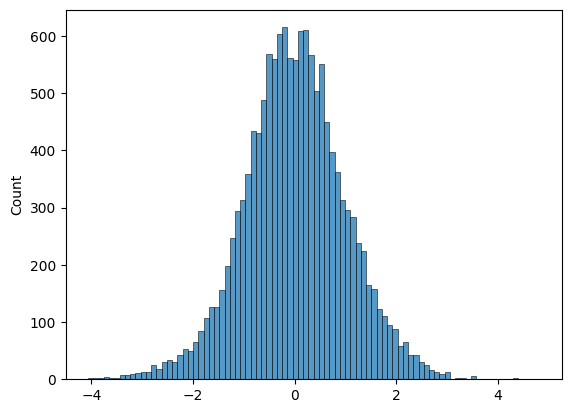

In [18]:
sns.histplot(StandardScaler().fit_transform(resid.values.reshape(-1,1)).ravel())

<Axes: ylabel='Count'>

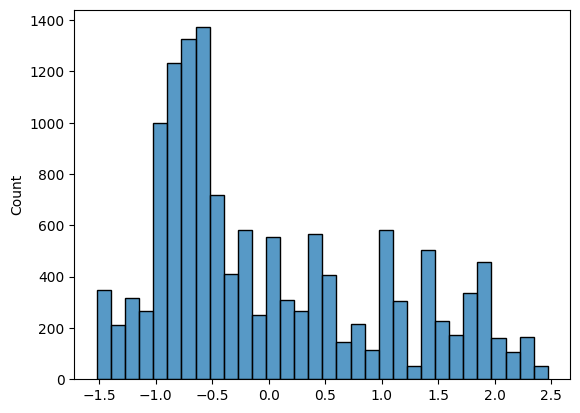

In [19]:
sns.histplot(StandardScaler().fit_transform(shap_values[:,:1]).ravel())

In [20]:
iom = InfluentialOutlierMetric()

In [28]:
results_iom = iom.find_best_lambda(
    StandardScaler().fit_transform(shap_values[:,:1]),
    lambdas = np.exp(np.linspace(-15, 0, 10)),
    K=13,
    hidden=13,
    layers=2,
    epoch=1000,
    loc=[0],
    scale=[1],
    tail_bound=2.5,
    num_bins=10,
    torch_seed=42
)

lambda: 3.059023205018258e-07
cuda


Normalizing flow: 100%|██████████| 1000/1000 [06:04<00:00,  2.75it/s]


--- Whitened mode-normality diagnostics (n=13726, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.0762

[1b] Stouffer combined normality p-value
     z = 1.4313
     p = 0.07618
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0000
    CvM p-value: 0.0555
    Q mean:      1.0064  expected approx d=1
    Q max:       8.1155
    min tail p:  0.004389
lambda: 1.6195967923126097e-06
cuda


Normalizing flow: 100%|██████████| 1000/1000 [06:01<00:00,  2.77it/s]

--- Whitened mode-normality diagnostics (n=13726, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.0067

[1b] Stouffer combined normality p-value
     z = 2.4723
     p = 0.006713
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0000
    CvM p-value: 0.0188
    Q mean:      0.9704  expected approx d=1
    Q max:       7.9293
    min tail p:  0.004864
Final lambda: 0.0000
Mean test distance: 0.1031
Final weights: [np.float32(1.0)]
Final means: [array([0.074], dtype=float32)]
Final scales: [array([0.8507], dtype=float32)]


In [29]:
results_iom_resid = iom.find_best_lambda(
    StandardScaler().fit_transform(resid.values.reshape(-1,1)),
    K=4,
    hidden=4,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=3,
    num_bins=8,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [00:58<00:00,  8.57it/s]


--- Whitened mode-normality diagnostics (n=13726, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.2083

[1b] Stouffer combined normality p-value
     z = 0.8123
     p = 0.2083
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.5852
    CvM p-value: 0.5235
    Q mean:      1.0189  expected approx d=1
    Q max:       21.6256
    min tail p:  3.314e-06
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [00:58<00:00,  8.48it/s]


--- Whitened mode-normality diagnostics (n=13726, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.1466

[1b] Stouffer combined normality p-value
     z = 1.0513
     p = 0.1466
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.6278
    CvM p-value: 0.5701
    Q mean:      1.0190  expected approx d=1
    Q max:       21.7074
    min tail p:  3.176e-06
lambda: 0.013123728736940968
cuda


Normalizing flow: 100%|██████████| 500/500 [00:58<00:00,  8.55it/s]


--- Whitened mode-normality diagnostics (n=13726, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.1056

[1b] Stouffer combined normality p-value
     z = 1.2500
     p = 0.1056
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.6328
    CvM p-value: 0.6427
    Q mean:      1.0186  expected approx d=1
    Q max:       21.7769
    min tail p:  3.063e-06
lambda: 0.025561533206507392
cuda


Normalizing flow: 100%|██████████| 500/500 [00:58<00:00,  8.58it/s]


--- Whitened mode-normality diagnostics (n=13726, d=1, m=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.0450

[1b] Stouffer combined normality p-value
     z = 1.6949
     p = 0.04505
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.5367
    CvM p-value: 0.6936
    Q mean:      1.0182  expected approx d=1
    Q max:       21.9206
    min tail p:  2.842e-06
Final lambda: 0.0131
Mean test distance: 0.0151
Final weights: [np.float32(1.0)]
Final means: [array([-0.0952], dtype=float32)]
Final scales: [array([1.0519], dtype=float32)]


In [30]:
iom.IOM(results_iom, results_iom_resid)

,IOM
0,0.827560
1,0.009918
2,0.027623
3,0.994992
4,0.160885
...,...
13721,0.005114
13722,0.006719
13723,0.766690
13724,0.000334


In [31]:
Data['IOM_i'] = iom.IOM_.values
Data['SHAP_z'] = results_iom['chi_z']
Data['resid_z'] = results_iom_resid['chi_z']

In [33]:
iom.find_threshold(p=1)

Threshold at 0.05: 4.761
Threshold at 0.01: 12.990


[4.760901368628315, 12.990352807262584]

In [32]:
Data[Data['IOM_i'] > 12.990352807262584].sort_values(by='IOM_i', ascending=False).shape

(137, 7)

In [83]:
Data[Data['IOM_i'] > 12.990352807262584].sort_values(by='IOM_i', ascending=False).head()

,CNT,CNTSCHID,PV1MATH,ESCS,IOM_i,SHAP_z,resid_z
CNTSTUID,,,,,,,
70202246.0,SGP,70200047.0,364.475,1.0895,87.393142,6.163805,14.178441
70203507.0,SGP,70200104.0,454.227,1.3628,62.884630,7.978248,7.882010
70204980.0,SGP,70200099.0,385.830,1.3463,45.106182,7.978248,5.653645
60800985.0,PHL,60800086.0,523.781,-0.8900,44.912111,5.526395,8.126838
60806859.0,PHL,60800039.0,498.450,-0.7296,44.349990,6.462263,6.862920


### School level

In [84]:
Data_group = pd.concat([pd.Series(best_model.group_map.keys()), pd.Series(best_model.bhat)], axis=1)
Data_group.columns = ['CNTSCHID', 'bhat']

In [85]:
Data_group_final = Data_group.merge(Data[['CNTSCHID', 'CNT']], on='CNTSCHID', how='left').drop_duplicates()
Data_group_final = Data_group_final.rename(columns={'CNT': 'Country'})

Text(0.5, 0, '')

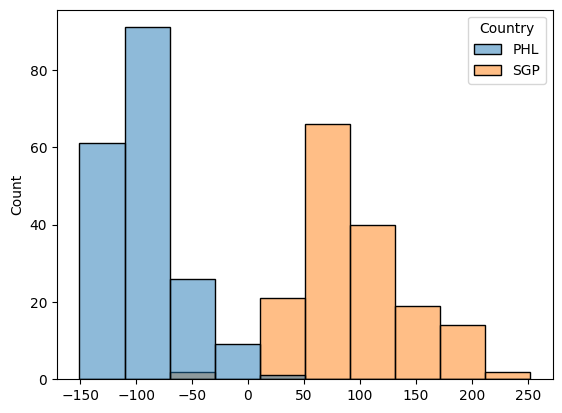

In [87]:
sns.histplot(Data_group_final, x='bhat', hue='Country')
plt.xlabel(None)

In [88]:
iom_sch = InfluentialOutlierMetric()

In [89]:
results_iom_sch_bm = iom_sch.find_best_lambda(
    best_model.bhat.reshape(-1,1),
    K=2,
    hidden=2,
    layers=2,
    epoch=500,
    loc=[-100, 100],
    scale=[50, 50],
    tail_bound=250,
    num_bins=16,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [00:24<00:00, 20.62it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 185  test: Jarque-Bera  pvalue: 0.2179
    mode: 1  n: 167  test: Jarque-Bera  pvalue: 0.3213

[1b] Stouffer combined normality p-value
     z = 0.8792
     p = 0.1896
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.9054
    CvM p-value: 0.9365
    Q mean:      0.9047  expected approx d=1
    Q max:       7.5601
    min tail p:  0.005968
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [00:24<00:00, 20.72it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 185  test: Jarque-Bera  pvalue: 0.2210
    mode: 1  n: 167  test: Jarque-Bera  pvalue: 0.3143

[1b] Stouffer combined normality p-value
     z = 0.8856
     p = 0.1879
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.9050
    CvM p-value: 0.9171
    Q mean:      0.9022  expected approx d=1
    Q max:       7.6029
    min tail p:  0.005827
lambda: 0.013123728736940968
cuda


...

--- Whitened mode-normality diagnostics (n=352, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 185  test: Jarque-Bera  pvalue: 0.2492
    mode: 1  n: 167  test: Jarque-Bera  pvalue: 0.2697

[1b] Stouffer combined normality p-value
     z = 0.9125
     p = 0.1807
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.7081
    CvM p-value: 0.5038
    Q mean:      0.8742  expected approx d=1
    Q max:       8.2652
    min tail p:  0.004041
lambda: 0.18887560283756177
cuda


Normalizing flow: 100%|██████████| 500/500 [00:25<00:00, 19.91it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 185  test: Jarque-Bera  pvalue: 0.2613
    mode: 1  n: 167  test: Jarque-Bera  pvalue: 0.2114

[1b] Stouffer combined normality p-value
     z = 1.0189
     p = 0.1541
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.4183
    CvM p-value: 0.2148
    Q mean:      0.8524  expected approx d=1
    Q max:       8.8070
    min tail p:  0.003001
lambda: 0.36787944117144233
cuda


Normalizing flow: 100%|██████████| 500/500 [00:25<00:00, 19.95it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 186  test: Jarque-Bera  pvalue: 0.2707
    mode: 1  n: 166  test: Jarque-Bera  pvalue: 0.0907

[1b] Stouffer combined normality p-value
     z = 1.3770
     p = 0.08425
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.0957
    CvM p-value: 0.0470
    Q mean:      0.8222  expected approx d=1
    Q max:       9.5104
    min tail p:  0.002043
Final lambda: 0.1889
Mean test distance: 153.3078
Final weights: [np.float32(0.5017), np.float32(0.4983)]
Final means: [array([-99.7824], dtype=float32), array([99.9872], dtype=float32)]
Final scales: [array([44.8049], dtype=float32), array([51.7358], dtype=float32)]


In [90]:
results_iom_sch_um = iom_sch.find_best_lambda(
    best_model.bhat.reshape(-1,1),
    K=2,
    hidden=2,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[100],
    tail_bound=250,
    num_bins=16,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [00:24<00:00, 20.13it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 352  test: Jarque-Bera  pvalue: 0.2345

[1b] Stouffer combined normality p-value
     z = 0.7241
     p = 0.2345
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.7004
    CvM p-value: 0.5330
    Q mean:      1.0014  expected approx d=1
    Q max:       7.9006
    min tail p:  0.004942
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [00:24<00:00, 20.36it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 352  test: Jarque-Bera  pvalue: 0.2227

[1b] Stouffer combined normality p-value
     z = 0.7631
     p = 0.2227
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.6625
    CvM p-value: 0.5229
    Q mean:      1.0004  expected approx d=1
    Q max:       7.9293
    min tail p:  0.004864
lambda: 0.013123728736940968
cuda


...

--- Whitened mode-normality diagnostics (n=352, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 352  test: Jarque-Bera  pvalue: 0.1473

[1b] Stouffer combined normality p-value
     z = 1.0481
     p = 0.1473
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.3198
    CvM p-value: 0.2409
    Q mean:      0.9949  expected approx d=1
    Q max:       8.0978
    min tail p:  0.004432
lambda: 0.09697196786440505
cuda


Normalizing flow: 100%|██████████| 500/500 [00:25<00:00, 19.74it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 352  test: Jarque-Bera  pvalue: 0.0792

[1b] Stouffer combined normality p-value
     z = 1.4102
     p = 0.07924
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.1961
    CvM p-value: 0.1397
    Q mean:      0.9835  expected approx d=1
    Q max:       8.3451
    min tail p:  0.003867
lambda: 0.18887560283756177
cuda


Normalizing flow: 100%|██████████| 500/500 [00:24<00:00, 20.03it/s]

--- Whitened mode-normality diagnostics (n=352, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 352  test: Jarque-Bera  pvalue: 0.0242

[1b] Stouffer combined normality p-value
     z = 1.9732
     p = 0.02424
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0314
    CvM p-value: 0.0245
    Q mean:      0.9732  expected approx d=1
    Q max:       8.5372
    min tail p:  0.00348
Final lambda: 0.0970
Mean test distance: 879.7668
Final weights: [np.float32(1.0)]
Final means: [array([0.1018], dtype=float32)]
Final scales: [array([87.7251], dtype=float32)]


In [91]:
iom_sch.select_flow_by_transport_modes([results_iom_sch_um, results_iom_sch_bm])

{'selected_index': 1,
 'table': [{'index': 0,
   'M': 879.766845703125,
   'n_modes': 1,
   'K_m': 2,
   'rho': np.float64(0.34657359027997264),
   'score': np.float64(880.4599928836849)},
  {'index': 1,
   'M': 153.30783081054688,
   'n_modes': 2,
   'K_m': 5,
   'rho': np.float64(0.34657359027997264),
   'score': np.float64(155.04069876194674)}]}

In [95]:
Data_group_final['bhat_z'] = results_iom_sch_bm['chi_z']

In [98]:
stats.chi2.ppf(0.99, df=1)

np.float64(6.6348966010212145)

In [99]:
Data_group_final[Data_group_final['bhat_z'] > stats.chi2.ppf(0.99, df=1)].sort_values(by='bhat_z', ascending=False)

,CNTSCHID,bhat,Country,bhat_z
7259,70200003.0,252.399612,SGP,8.807044
7167,70200001.0,239.680725,SGP,7.476907


## Full model

In [90]:
Data = spark.read.parquet("/content/drive/MyDrive/pisa_spark_stu/").select("CNT", 'CNTSCHID', 'CNTSTUID', "PV1MATH", "ESCS", "MATHEFF", "MATHPERS").filter(F.col("CNT").isin("SGP", "PHL")).toPandas().dropna()
Data['CNTSCHID'] = Data['CNTSCHID'].astype(str)

In [ ]:
Data['CNT'] = pd.get_dummies(Data['CNT'], drop_first=True).astype(int) #PHL = 0

In [8]:
Data_sch = pd.read_spss("/content/drive/MyDrive/PISA/CY08MSP_SCH_QQQ.SAV")[["CNTSCHID", "PROPMATH"]].dropna()
Data_sch['CNTSCHID'] = Data_sch['CNTSCHID'].astype(str)

In [9]:
Data_final = Data.merge(Data_sch, on="CNTSCHID", how="left").dropna()
Data_final = Data_final.set_index('CNTSTUID')

In [27]:
Data_final

,CNT,CNTSCHID,PV1MATH,ESCS,MATHEFF,MATHPERS,PROPMATH
CNTSTUID,,,,,,,
60806165.0,0,60800182.0,370.444,0.2782,-1.8037,-0.7105,0.1273
60806166.0,0,60800024.0,314.718,-2.6258,0.1777,-0.4530,0.1087
60806167.0,0,60800142.0,268.274,-0.9840,-1.2857,-1.1216,0.1382
60806170.0,0,60800150.0,316.133,-2.3435,-0.2575,-0.6146,0.1429
60806171.0,0,60800009.0,298.137,0.3207,-0.5574,-0.3073,0.1304
...,...,...,...,...,...,...,...
60806158.0,0,60800119.0,392.198,-1.8552,2.2512,0.7827,1.0000
60806160.0,0,60800113.0,395.818,0.2381,-0.0559,0.1930,0.1124
60806161.0,0,60800022.0,406.132,-1.3717,-3.4876,-0.7219,0.1250


In [10]:
X = Data_final.drop(columns=['CNTSCHID', 'PV1MATH'])
y = Data_final['PV1MATH']
groups = Data_final['CNTSCHID']

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(X, y, groups, test_size=0.2, random_state=42)

In [14]:
best_megb = tune_megb_cpu(X_train, y_train, groups_train, n_trials=32)

[I 2026-08-17 18:27:42,411] A new study created in memory with name: no-name-b83c1310-ab05-4815-ad0f-29ba84d0fdf3


  0%|          | 0/32 [00:00<?, ?it/s]

[I 2026-08-17 18:27:50,606] Trial 1 finished with value: 66.80440464244833 and parameters: {'learning_rate': 0.18296539422253233, 'max_depth': 3, 'subsample': 0.8777077670645246, 'colsample_bytree': 0.9118757670366067, 'min_child_weight': 5, 'gamma': 1.747368269382487, 'max_iter': 6, 'tol': 0.0006079237003884827}. Best is trial 1 with value: 66.80440464244833.
[I 2026-08-17 18:27:51,513] Trial 2 finished with value: 70.60180452336802 and parameters: {'learning_rate': 0.19659315791150803, 'max_depth': 6, 'subsample': 0.6367010288969127, 'colsample_bytree': 0.6836612806004448, 'min_child_weight': 5, 'gamma': 1.3358416358346352, 'max_iter': 5, 'tol': 0.0003447752074673424}. Best is trial 1 with value: 66.80440464244833.
[I 2026-08-17 18:27:54,546] Trial 5 finished with value: 66.53040038719068 and parameters: {'learning_rate': 0.05045552973074163, 'max_depth': 5, 'subsample': 0.8811763474151748, 'colsample_bytree': 0.9196866252172455, 'min_child_weight': 6, 'gamma': 0.9538286468461232, 'm

In [15]:
megb_params = ['max_iter', 'tol']
xgb_params = {k: v for k, v in best_megb.items() if k not in megb_params}

# Initialize MEGB with unpacked parameters
best_model = MEGB_CPU(
    xgb_params=xgb_params,
    max_iter=best_megb.get('max_iter', 10),
    tol=best_megb.get('tol', 1e-4)
)

best_model.fit(X_train, y_train, groups_train)

In [16]:
print("Test RMSE:", np.sqrt(mean_squared_error(best_model.predict(X_test, groups_test), y_test)))

Test RMSE: 64.02511825929747


### Student level

In [28]:
shap_values = best_model.booster.predict(
    xgb.DMatrix(np.asarray(Data_final.drop(columns=['CNTSCHID', 'PV1MATH']).values, dtype=np.float32)),
    pred_contribs=True
)

In [29]:
shap_values = pd.DataFrame(shap_values)
shap_values.columns = ['CNT', 'ESCS',"MATHEFF", "MATHPERS", "PROPMATH", 'Intercept']

In [19]:
resid = Data_final['PV1MATH'] - best_model.predict(Data_final.drop(columns=['CNTSCHID', 'PV1MATH']), Data_final['CNTSCHID'])

<Axes: ylabel='Count'>

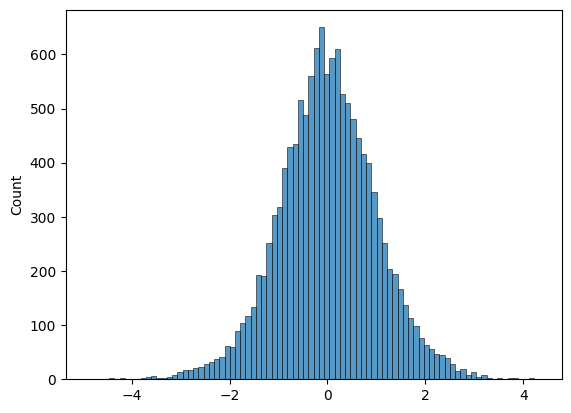

In [20]:
sns.histplot(StandardScaler().fit_transform(resid.values.reshape(-1,1)).ravel())

<Axes: ylabel='Count'>

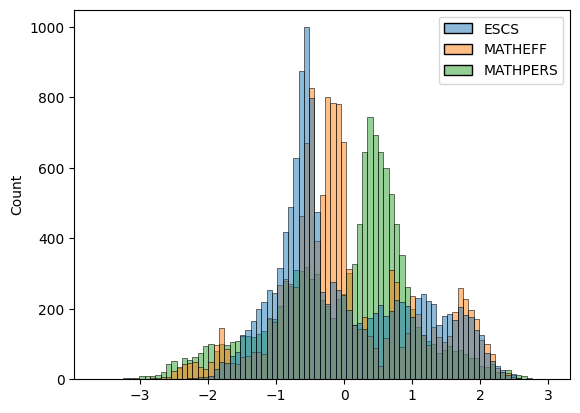

In [30]:
shap_values_stu_s = pd.DataFrame(StandardScaler().fit_transform(shap_values[['ESCS', "MATHEFF", "MATHPERS"]]), columns= ['ESCS', "MATHEFF", "MATHPERS"])
sns.histplot(shap_values_stu_s)

In [31]:
iom = InfluentialOutlierMetric()

In [41]:
results_iom = iom.find_best_lambda(
    shap_values_stu_s.values,
    context=Data_final['CNT'].values,
    K=14,
    hidden=14,
    layers=2,
    epoch=1000,
    loc=[0],
    scale=[1],
    tail_bound=3.8,
    num_bins=13,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 1000/1000 [08:06<00:00,  2.06it/s]


--- Whitened mode-normality diagnostics (n=12955, d=3, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Henze-Zirkler  pvalue: 0.0696

[1b] Stouffer combined normality p-value
     z = 1.4785
     p = 0.06964
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.8873
    CvM p-value: 0.9079
    Q mean:      2.9973  expected approx d=3
    Q max:       21.7987
    min tail p:  7.183e-05
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 1000/1000 [08:05<00:00,  2.06it/s]


--- Whitened mode-normality diagnostics (n=12955, d=3, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Henze-Zirkler  pvalue: 0.0459

[1b] Stouffer combined normality p-value
     z = 1.6865
     p = 0.04585
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.1837
    CvM p-value: 0.0939
    Q mean:      2.9660  expected approx d=3
    Q max:       23.9708
    min tail p:  2.533e-05
Final lambda: 0.0000
Mean test distance: 0.9601
Final weights: [np.float32(1.0)]
Final means: [array([ 0.0084, -0.0157, -0.0246], dtype=float32)]
Final scales: [array([0.9595, 0.9389, 0.9647], dtype=float32)]


In [73]:
results_iom_resid = iom.find_best_lambda(
    StandardScaler().fit_transform(resid.values.reshape(-1,1)),
    context=Data_final['CNT'].values,
    lambdas=np.exp(np.linspace(-5, 1, 10)), 
    K=12,
    hidden=12,
    layers=3,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=4.8,
    num_bins=8,
    torch_seed=42
)

lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [03:09<00:00,  2.64it/s]


--- Whitened mode-normality diagnostics (n=12955, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Jarque-Bera  pvalue: 0.9066

[1b] Stouffer combined normality p-value
     z = -1.3201
     p = 0.9066
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0798
    CvM p-value: 0.0663
    Q mean:      1.0284  expected approx d=1
    Q max:       23.1930
    min tail p:  1.465e-06
lambda: 0.013123728736940968
cuda


Normalizing flow: 100%|██████████| 500/500 [03:07<00:00,  2.66it/s]


--- Whitened mode-normality diagnostics (n=12955, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Jarque-Bera  pvalue: 0.9013

[1b] Stouffer combined normality p-value
     z = -1.2891
     p = 0.9013
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0355
    CvM p-value: 0.0773
    Q mean:      1.0278  expected approx d=1
    Q max:       23.5091
    min tail p:  1.243e-06
lambda: 0.025561533206507392
cuda


...

--- Whitened mode-normality diagnostics (n=12955, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Jarque-Bera  pvalue: 0.4793

[1b] Stouffer combined normality p-value
     z = 0.0519
     p = 0.4793
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.1372
    CvM p-value: 0.0907
    Q mean:      1.0320  expected approx d=1
    Q max:       25.5337
    min tail p:  4.347e-07
lambda: 0.18887560283756177
cuda


Normalizing flow: 100%|██████████| 500/500 [03:05<00:00,  2.70it/s]


--- Whitened mode-normality diagnostics (n=12955, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Jarque-Bera  pvalue: 0.1976

[1b] Stouffer combined normality p-value
     z = 0.8503
     p = 0.1976
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.2572
    CvM p-value: 0.2155
    Q mean:      1.0313  expected approx d=1
    Q max:       25.8441
    min tail p:  3.701e-07
lambda: 0.36787944117144233
cuda


Normalizing flow: 100%|██████████| 500/500 [03:05<00:00,  2.70it/s]


--- Whitened mode-normality diagnostics (n=12955, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Jarque-Bera  pvalue: 0.0225

[1b] Stouffer combined normality p-value
     z = 2.0046
     p = 0.0225
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.7355
    CvM p-value: 0.5315
    Q mean:      1.0285  expected approx d=1
    Q max:       25.9288
    min tail p:  3.542e-07
Final lambda: 0.1889
Mean test distance: 0.0226
Final weights: [np.float32(1.0)]
Final means: [array([-0.0097], dtype=float32)]
Final scales: [array([0.9602], dtype=float32)]


In [74]:
iom.IOM(results_iom, results_iom_resid)

,IOM
0,5.018100
1,0.508597
2,2.564628
3,0.002855
4,0.920686
...,...
12950,0.991599
12951,0.236444
12952,5.397263
12953,0.999187


In [75]:
Data_final['IOM_i'] = iom.IOM_.values
Data_final['SHAP_z'] = results_iom['chi_z']
Data_final['resid_z'] = results_iom_resid['chi_z']

In [76]:
iom.find_threshold(p=3)

Threshold at 0.05: 12.984
Threshold at 0.01: 28.695


[12.9843375948851, 28.695046476162922]

In [77]:
Data_final[Data_final['IOM_i'] > 28.695].sort_values(by='IOM_i', ascending=False)

,CNT,CNTSCHID,PV1MATH,ESCS,MATHEFF,MATHPERS,PROPMATH,IOM_i,SHAP_z,resid_z
CNTSTUID,,,,,,,,,,
70203381.0,1,70200076.0,943.041,1.1072,2.1839,0.9681,0.1244,172.182727,11.695597,14.722013
70206879.0,1,70200102.0,343.089,-0.4264,1.8672,2.7166,0.2347,106.325668,16.966118,6.266941
60806855.0,0,60800074.0,200.888,-3.1790,-0.5502,1.1423,0.1545,105.483547,11.849996,8.901568
70202621.0,1,70200120.0,339.756,-2.0910,0.7990,2.0379,0.3675,100.758567,17.700471,5.692423
70203715.0,1,70200107.0,254.384,-0.3533,2.2559,2.0718,0.1485,95.337345,8.338921,11.432815
...,...,...,...,...,...,...,...,...,...,...
70205563.0,1,70200059.0,368.566,0.9252,-3.4030,0.2371,0.1573,29.394732,10.997961,2.672744
70203973.0,1,70200080.0,433.337,1.3158,-0.0646,-0.4771,0.1364,29.273519,4.910767,5.961090
70201259.0,1,70200003.0,883.094,1.3233,1.4999,0.5737,0.2134,28.943040,10.434574,2.773764


In [78]:
Data_final[Data_final['IOM_i'] > 28.695].sort_values(by='IOM_i', ascending=False).head()

,CNT,CNTSCHID,PV1MATH,ESCS,MATHEFF,MATHPERS,PROPMATH,IOM_i,SHAP_z,resid_z
CNTSTUID,,,,,,,,,,
70203381.0,1,70200076.0,943.041,1.1072,2.1839,0.9681,0.1244,172.182727,11.695597,14.722013
70206879.0,1,70200102.0,343.089,-0.4264,1.8672,2.7166,0.2347,106.325668,16.966118,6.266941
60806855.0,0,60800074.0,200.888,-3.1790,-0.5502,1.1423,0.1545,105.483547,11.849996,8.901568
70202621.0,1,70200120.0,339.756,-2.0910,0.7990,2.0379,0.3675,100.758567,17.700471,5.692423
70203715.0,1,70200107.0,254.384,-0.3533,2.2559,2.0718,0.1485,95.337345,8.338921,11.432815


### School level

<Axes: ylabel='Count'>

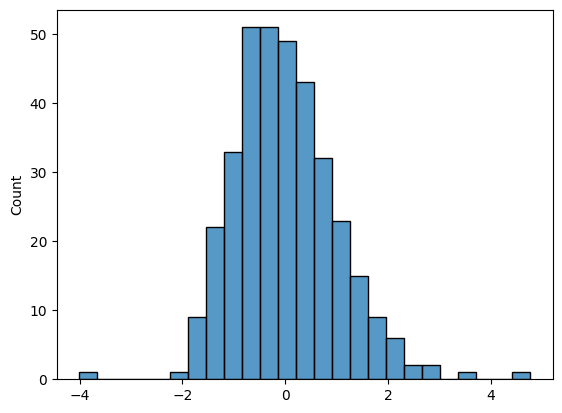

In [79]:
sns.histplot(StandardScaler().fit_transform(best_model.bhat.reshape(-1,1)).ravel())

In [80]:
Data_final['PROPMATH'] = pd.to_numeric(Data_final['PROPMATH'])

In [81]:
Data_final_sch = (
    Data_final
    .groupby("CNTSCHID", as_index=False)
    .agg({
        **{
            col: "mean"
            for col in Data_final.select_dtypes(include="number").columns
            if col != "CNTSCHID"
        },
        "CNT": "first",
    })
)[['CNT', 'CNTSCHID', 'PROPMATH', 'PV1MATH']]

In [82]:
shap_values['CNTSCHID'] = Data_final['CNTSCHID'].values
shap_sch = shap_values[["PROPMATH", 'CNTSCHID']].groupby("CNTSCHID").mean().reset_index()

In [83]:
shap_sch_final = shap_sch.merge(Data_final_sch[['CNT', 'CNTSCHID']], how='left', on='CNTSCHID')

<Axes: ylabel='Count'>

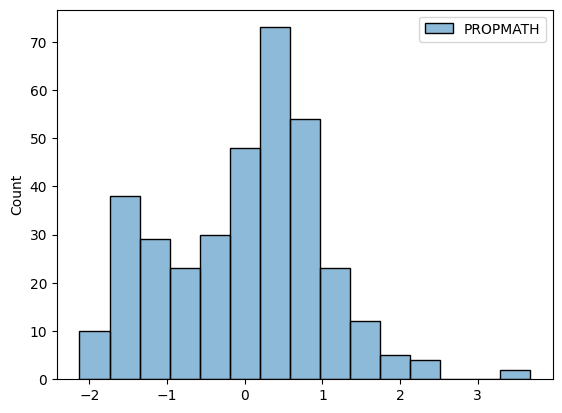

In [84]:
shap_sch_s = pd.DataFrame(StandardScaler().fit_transform(shap_sch_final[['PROPMATH']].values), columns = ["PROPMATH"])
sns.histplot(shap_sch_s)

In [85]:
iom_sch = InfluentialOutlierMetric()

In [86]:
results_iom_sch = iom_sch.find_best_lambda(
    shap_sch_s.values,
    context = shap_sch_final[['CNT']].values,
    lambdas=[10**10],
    K=2,
    hidden=2,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=3,
    num_bins=8,
    torch_seed=42
)

lambda: 10000000000
cuda


Normalizing flow: 100%|██████████| 500/500 [00:27<00:00, 18.41it/s]

--- Whitened mode-normality diagnostics (n=351, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.8374

[1b] Stouffer combined normality p-value
     z = -0.9839
     p = 0.8374
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.4915
    CvM p-value: 0.4965
    Q mean:      0.9562  expected approx d=1
    Q max:       12.8330
    min tail p:  0.0003406
Final lambda: 10000000000.0000
Mean test distance: 0.0000
Final weights: [np.float32(1.0)]
Final means: [array([-0.], dtype=float32)]
Final scales: [array([1.0227], dtype=float32)]


In [87]:
cnt = pd.DataFrame(pd.Series(list(best_model.group_map.keys()),name='CNTSCHID')).merge(Data_final_sch, on='CNTSCHID')['CNT']

In [88]:
results_iom_sch_resid = iom_sch.find_best_lambda(
    StandardScaler().fit_transform(best_model.bhat.reshape(-1,1)),
    context=cnt.values,
    K=4,
    hidden=4,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=5,
    num_bins=14,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [00:54<00:00,  9.24it/s]


--- Whitened mode-normality diagnostics (n=351, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.6553

[1b] Stouffer combined normality p-value
     z = -0.3996
     p = 0.6553
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9454
    CvM p-value: 0.9823
    Q mean:      0.9855  expected approx d=1
    Q max:       7.6487
    min tail p:  0.005681
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [00:53<00:00,  9.27it/s]


--- Whitened mode-normality diagnostics (n=351, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.6736

[1b] Stouffer combined normality p-value
     z = -0.4499
     p = 0.6736
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9939
    CvM p-value: 0.9913
    Q mean:      0.9749  expected approx d=1
    Q max:       7.6145
    min tail p:  0.00579
lambda: 0.013123728736940968
cuda


...

--- Whitened mode-normality diagnostics (n=351, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.1543

[1b] Stouffer combined normality p-value
     z = 1.0183
     p = 0.1543
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9306
    CvM p-value: 0.9594
    Q mean:      0.9641  expected approx d=1
    Q max:       8.1970
    min tail p:  0.004196
lambda: 1.395612425086089
cuda


Normalizing flow: 100%|██████████| 500/500 [00:53<00:00,  9.29it/s]


--- Whitened mode-normality diagnostics (n=351, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.0670

[1b] Stouffer combined normality p-value
     z = 1.4984
     p = 0.06701
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9378
    CvM p-value: 0.9441
    Q mean:      0.9710  expected approx d=1
    Q max:       9.3685
    min tail p:  0.002207
lambda: 2.718281828459045
cuda


Normalizing flow: 100%|██████████| 500/500 [00:53<00:00,  9.34it/s]


--- Whitened mode-normality diagnostics (n=351, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.0000

[1b] Stouffer combined normality p-value
     z = 4.9815
     p = 3.154e-07
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9333
    CvM p-value: 0.8723
    Q mean:      0.9720  expected approx d=1
    Q max:       22.6287
    min tail p:  1.965e-06
Final lambda: 1.3956
Mean test distance: 0.0200
Final weights: [np.float32(1.0)]
Final means: [array([0.1058], dtype=float32)]
Final scales: [array([0.9084], dtype=float32)]


In [92]:
iom_sch.IOM(results_iom_sch, results_iom_sch_resid)

,IOM
0,0.374931
1,0.092385
2,0.010272
3,0.045593
4,0.340823
...,...
346,0.926600
347,2.617707
348,0.103343
349,5.725798


In [93]:
Data_final_sch['IOM_j'] = iom_sch.IOM_.values
Data_final_sch['SHAP_z'] = results_iom_sch['chi_z']
Data_final_sch['resid_z'] = results_iom_sch_resid['chi_z']

In [94]:
iom_test= InfluentialOutlierMetric()
iom_test.find_threshold(p=1)

Threshold at 0.05: 4.761
Threshold at 0.01: 12.990


[4.760901368628315, 12.990352807262584]

In [95]:
Data_final_sch[Data_final_sch['IOM_j'] > 12.990352807262584].sort_values(by=['IOM_j'], ascending=False).head()

,CNT,CNTSCHID,PROPMATH,PV1MATH,IOM_j,SHAP_z,resid_z
188,1,70200001.0,0.1385,728.378907,57.559430,12.833050,4.485249
287,1,70200101.0,0.1384,698.928000,35.630470,10.757748,3.312075
335,1,70200149.0,0.1963,391.408259,18.159510,3.926746,4.624570
187,0,60800188.0,0.1471,453.868615,14.465423,2.693487,5.370518
248,1,70200062.0,0.1475,690.248456,13.709904,5.363343,2.556224
